## Polytope Climate-DT Box Timeseries cut-out example notebook

This notebook shows how to use earthkit-data and earthkit-plots to pull destination-earth data from LUMI and plot it using earthkit-plots.

Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [2]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install earthkit-geo
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

If you do not have eccodes installed please install eccodes using conda as it is a dependency of earthkit, or install earthkit via conda

* conda install eccodes -c conda-forge
* conda install earthkit-data -c conda-forge

In [2]:
import earthkit.data
import earthkit.plots
import earthkit.geo.cartography
from polytope.api import Client

In [3]:
# Set True if you want to make a live request for the data, or false if you want to use the cached grib file
LIVE_REQUEST = True

In [4]:
request = {
    "activity": "scenariomip",
    "class": "d1",
    "dataset": "climate-dt",
    "experiment": "ssp3-7.0",
    "generation": "1",
    "levtype": "sfc",
    "date": "20200101/to/20300101",
    "model": "ifs-nemo",
    "expver": "0001",
    "param": "167",
    "realization": "1",
    "resolution": "high",
    "stream": "clte",
    "type": "fc",
    "time": "1200",
    "feature": {
        "type": "boundingbox",
        "points" : [[53.55, 6.76], [52.66, 7.86]],
    },
}

In [ ]:
data_file = "data/climate-dt-earthkit-fe-box-timeseries.covjson"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file) 

In [6]:
ds = data.to_xarray()
ds

<xarray.Dataset> Size: 5MB
Dimensions:    (datetimes: 3654, number: 1, steps: 1, points: 177)
Coordinates:
  * datetimes  (datetimes) <U20 292kB '2020-01-01T12:00:00Z' ... '2030-01-01T...
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 1kB 0 1 2 3 4 5 6 ... 170 171 172 173 174 175 176
    latitude   (points) float64 1kB 52.71 52.71 52.71 ... 53.52 53.52 53.52
    longitude  (points) float64 1kB 7.35 7.238 7.799 7.687 ... 7.28 7.051 6.822
    levelist   (points) float64 1kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    2t         (datetimes, number, steps, points) float64 5MB 275.4 ... 274.3
Attributes: (12/16)
    activity:       scenariomip
    class:          d1
    dataset:        climate-dt
    Forecast date:  2020-01-01T12:00:00Z
    experiment:     ssp3-7.0
    expver:         0001
    ...             ...
    resolution:     high
    stream:         clte
    type:           fc
    number:         0
    step:           0
    date:           2020-01-01T12:00:00Z

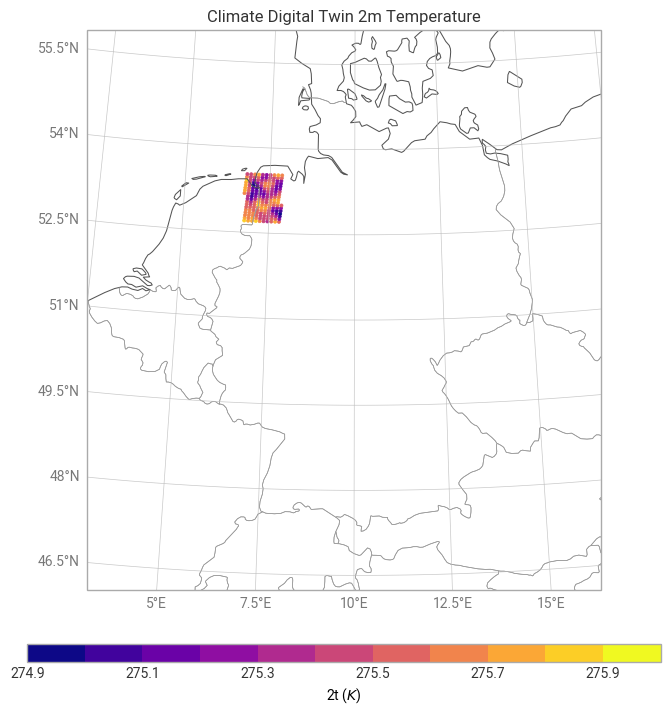

In [14]:
chart = earthkit.plots.Map(domain=["Netherlands", "Germany"])

ds_day_1 = ds['2t'].isel(datetimes=0)

chart.point_cloud(
    ds_day_1,
    x="longitude",
    y="latitude",
    auto_style=True
)

chart.coastlines()
chart.borders()
chart.gridlines()

chart.title("Climate Digital Twin 2m Temperature")

chart.legend()

chart.show()